In [9]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_original as ut
import EI.ei_open_loop as eol
import EI.ei_unified as eu
import EI.ei_jax as ej

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import plot_phase_diag, plot_energies_uv, plot_nalpha_beta, plot_nalpha_beta_bz

In [10]:
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png", dpi=300)


In [11]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [12]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
m0 = s0.m
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"m_0     = {m0}")
logger.info(f"mu0     = {mu0}")
logger.info(f"T_c     = {tc}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[16:51:43] [INFO    ] Delta_0 = 0.5809134191868265
[16:51:43] [INFO    ] m_0     = -0.8885755524481596
[16:51:43] [INFO    ] mu0     = 2.2499999999999156
[16:51:43] [INFO    ] T_c     = 0.30497106697708365


In [13]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [14]:
bc = op["bath"]

rf = getattr(ej, bc["rate"])

bpars = dict(bc["pars"])
bpars["rate"] = rf

set mu_B = E_c

In [15]:
Ec = md["mean_field"]["v"] * md["mean_field"]["n"] /2 + (md["band"]["pars"]["ta"] + md["band"]["pars"]["tb"]) / (2 * (md["band"]["pars"]["ta"] - md["band"]["pars"]["tb"])) * (md["mean_field"]["v"] * s0.m - md["band"]["pars"]["gap"])
logger.info(f"E_c = {Ec}")

bpars["mu"] = Ec

[16:51:43] [INFO    ] E_c = 2.25


In [86]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)
gd = np.full((nt, nt), np.nan)
gi = np.full((nt, nt), np.nan)

# de = s0.d
# me = s0.m


# for j in tqdm(range(nt), desc="T2"):
#     t2 = t2a[j]
#     se = eu.solve_eq(bd, p, t=t2,
#         d=max(abs(de), 1.0e-6),
#         m=me,
#         mix=(0.15, 0.15),
#         tol=1.0e-9,
#         nmax=20000,
#         chk=20,
#         prog=False,
#     )

#     n = se.n.copy()
#     d = se.d
#     m = se.m

#     for i in tqdm(
#         range(j, nt),
#         desc="T1",
#         leave=False,
#     ):
#         t1 = t1a[i]
#         bs = (ej.gam_db(t=t1, name="bath 1", **bpars),
#               ej.gam_db(t=t2, name="bath 2", **bpars))

#         so = ej.solve_open(bd, p, n, bs, d=d, m=m, **op["solve"])

#         ds = 0.1 * d0

#         da[j, i] = abs(so.d)
#         ma[j, i] = so.m
#         er[j, i] = so.err
#         it[j, i] = so.it
#         ok[j, i] = so.ok

#         #update
#         n = so.n.copy()
#         d = max(abs(so.d), ds)
#         m = so.m

#         da[i, j] = da[j, i]
#         ma[i, j] = ma[j, i]
#         er[i, j] = er[j, i]
#         it[i, j] = it[j, i]
#         ok[i, j] = ok[j, i]

de = s0.d
me = s0.m

ds = 1.0e-6 * max(d0, 1.0)

for j in tqdm(range(nt), desc="T2"):
    t2 = t2a[j]

    se = eu.solve_eq(
        bd, p, t=t2,
        d=max(abs(de), 1.0e-8),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1",
        leave=False,
    ):
        t1 = t1a[i]

        bs = (
            ej.gam_db(t=t1, name="bath 1", **bpars),
            ej.gam_db(t=t2, name="bath 2", **bpars),
        )

        so = ej.solve_open(
            bd, p, n, bs,
            d=d, m=m,
            **op["solve"],
        )

        ee = np.asarray(so.st.e)

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        gd[j, i] = np.min(ee[0] - ee[1])
        gi[j, i] = np.min(ee[0]) - np.max(ee[1])

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]
        gd[i, j] = gd[j, i]
        gi[i, j] = gi[j, i]

    de = se.d
    me = se.m

T2: 100%|██████████| 150/150 [05:17<00:00,  2.12s/it]


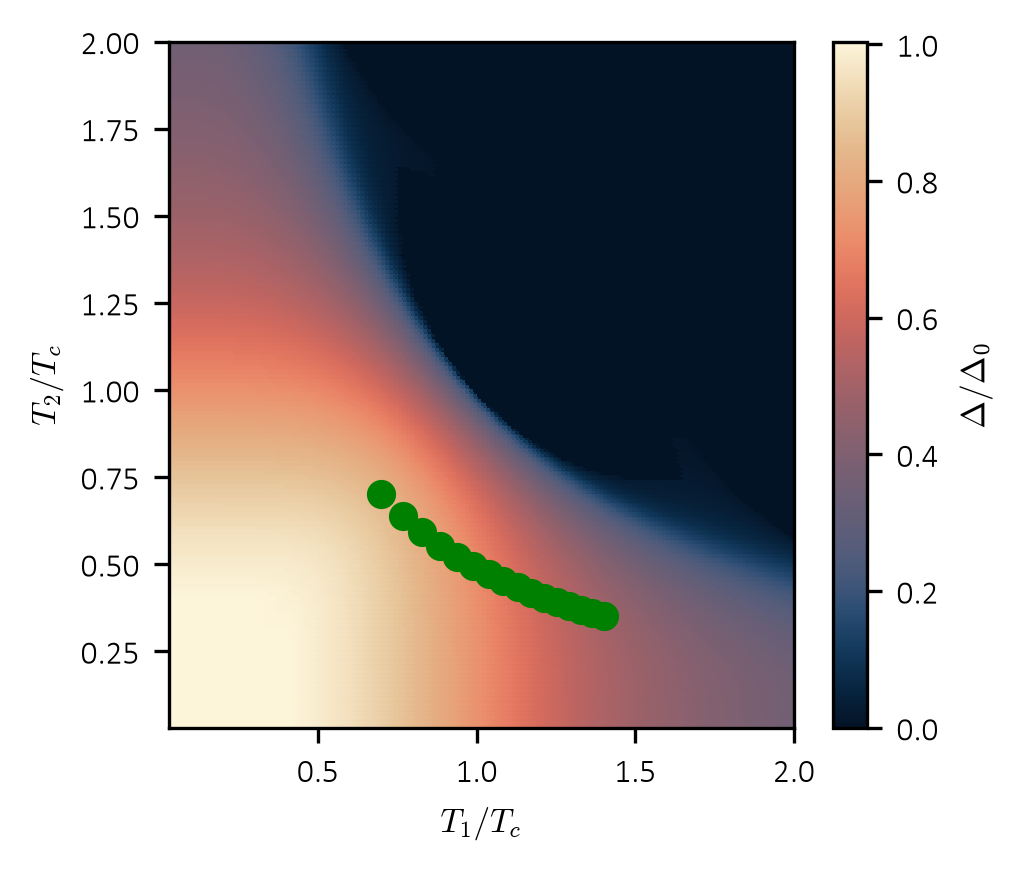

In [87]:
plot_phase_diag(da, d0, tn, config = cfg, OUT=OUT, name="phase_diag_test", save=False)

In [16]:
rs = cfg["ratio_sweep"]

x0 = rs["x0"]
r = np.arange(rs["r_min"], rs["r_max"] + rs["r_step"], rs["r_step"])
x1a = x0 * np.sqrt(r)
x2a = x0 / np.sqrt(r)

t0 = x0 * tc

band = getattr(eu, md["band"]["name"])
bd_dense = band(md["nk"]["reference"], **md["band"]["pars"])
p = eu.MFPars(**md["mean_field"])

se = eu.solve_eq(bd_dense, p, t=t0, d=max(abs(s0.d), 1.0e-4), m=s0.m, **eq["solve"])

nk1 = int(round(np.sqrt(se.n.shape[1])))

c = nk1 // 2
q = np.arange(c + 1)

i1 = c - q
j1 = np.full_like(q, c)

i2 = np.zeros(c, dtype=int)
j2 = c - np.arange(1, c + 1)

i3 = np.arange(1, c + 1)
j3 = np.arange(1, c + 1)

ii = np.concatenate((i1, i2, i3))
jj = np.concatenate((j1, j2, j3))

s1 = np.linspace(0.0, np.pi, c + 1)
s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
s3 = np.linspace(2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi, c + 1)[1:]

ks = np.concatenate((s1, s2, s3))

kt = [0.0, np.pi, 2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi]
kl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]


def path(n):
    n = np.asarray(n)
    na = n[0].reshape(nk1, nk1)[ii, jj]
    nb = n[1].reshape(nk1, nk1)[ii, jj]
    return na, nb


def path1(z):
    z = np.asarray(z).reshape(nk1, nk1)
    return z[ii, jj]


nea, neb = path(se.n)

gam_pars = dict(op["bath"]["pars"])
gam_pars["rate"] = getattr(ej, op["bath"]["rate"])

naa = np.empty((x2a.size, ks.size))
nba = np.empty_like(naa)
da1 = np.empty(x2a.size)
era = np.empty(x2a.size)
oka = np.empty(x2a.size, dtype=bool)

eaa = np.empty_like(naa)
eba = np.empty_like(naa)
ua = np.empty_like(naa)
va = np.empty_like(naa)

eah = np.empty_like(naa)
ebh = np.empty_like(naa)

nfa = np.empty((r.size, 2, nk1, nk1))

n = se.n.copy()
d = se.d
m = se.m

bar = tqdm(range(r.size), desc="Ratio sweep")

for q in bar:
    x1 = x1a[q]
    x2 = x2a[q]

    t1 = x1 * tc
    t2 = x2 * tc

    bs = (
        ej.gam_db(t1, name="bath 1", **gam_pars),
        ej.gam_db(t2, name="bath 2", **gam_pars),
    )

    sp = ej.solve_open(bd_dense, p, n, bs, d=d, m=m, **op["solve"])
    
    nfa[q] = np.asarray(sp.n).reshape(2, nk1, nk1)
    naa[q], nba[q] = path(sp.n)
    da1[q] = abs(sp.d)
    era[q] = sp.err
    oka[q] = sp.ok

    eaa[q], eba[q] = path(sp.st.e)
    ua[q] = path1(sp.st.u)
    va[q] = path1(sp.st.v)

    eah[q] = path1(sp.st.eah)
    ebh[q] = path1(sp.st.ebh)

    n = sp.n.copy()
    d = sp.d
    m = sp.m

    bar.set_postfix(r=f"{r[q]:.2f}", t1=f"{x1:.2f}", t2=f"{x2:.2f}", d=f"{abs(sp.d):.3e}", err=f"{sp.err:.2e}")

print("All converged:", np.all(oka))
print("Largest error:", np.max(era))

Ratio sweep:   6%|▋         | 1/16 [00:35<08:45, 35.02s/it, d=4.878e-01, err=2.59e-08, r=1.00, t1=0.70, t2=0.70]


KeyboardInterrupt: 

Plotting: 100%|██████████| 16/16 [00:00<00:00, 2831.12it/s]
/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


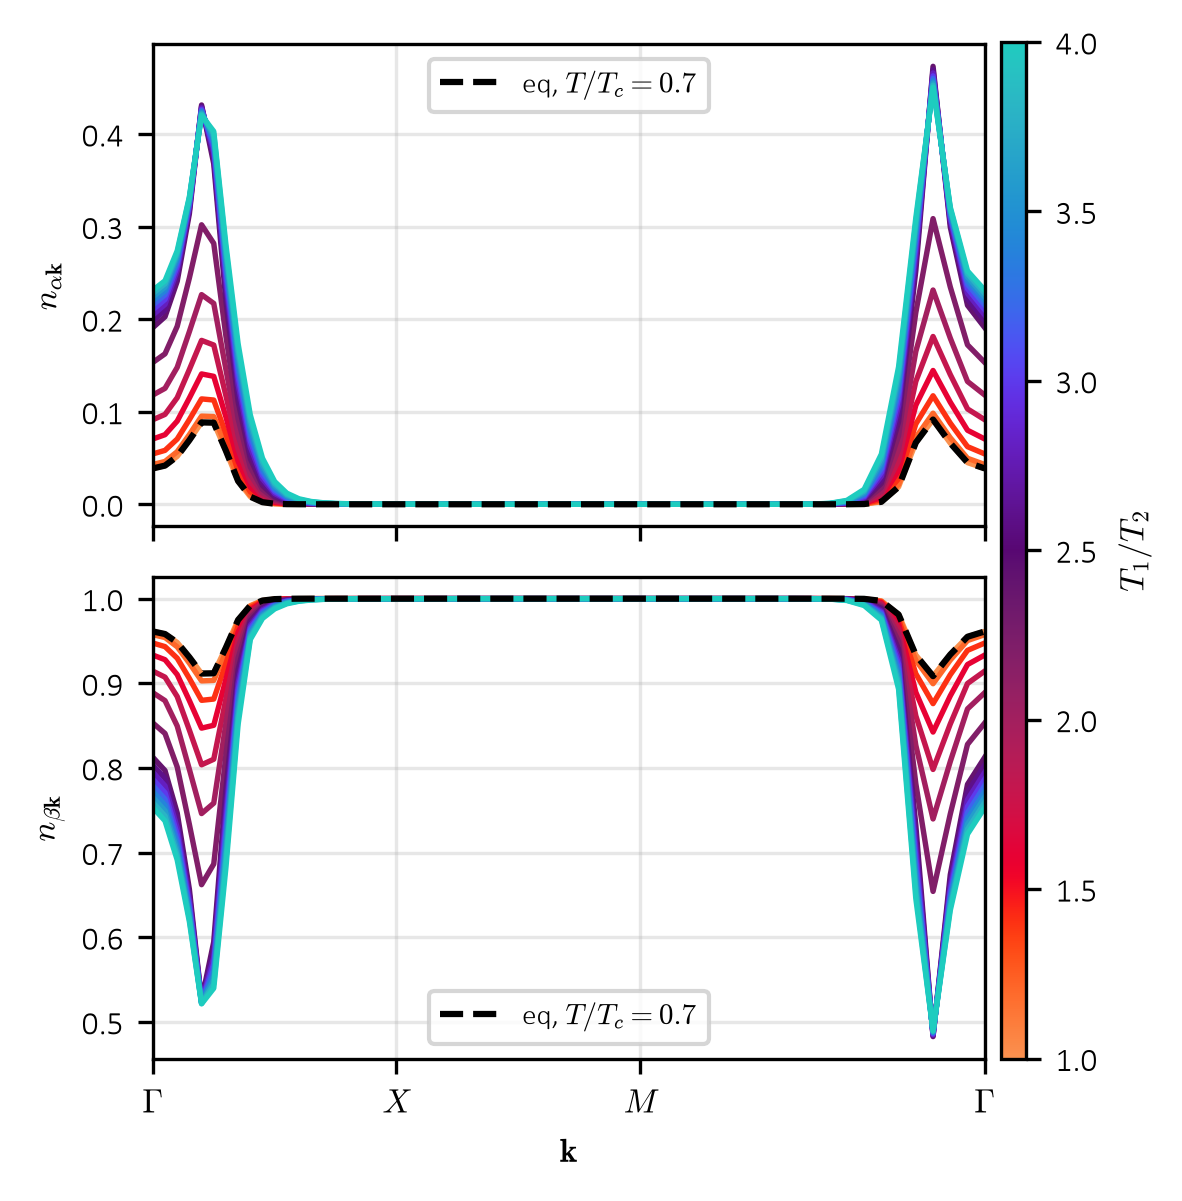

In [ ]:
plot_nalpha_beta(naa, nba, nea, neb, r, ks, kt, kl,cfg, OUT=OUT, name="nalpha_beta_test", save=False, overwrite=True)

/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


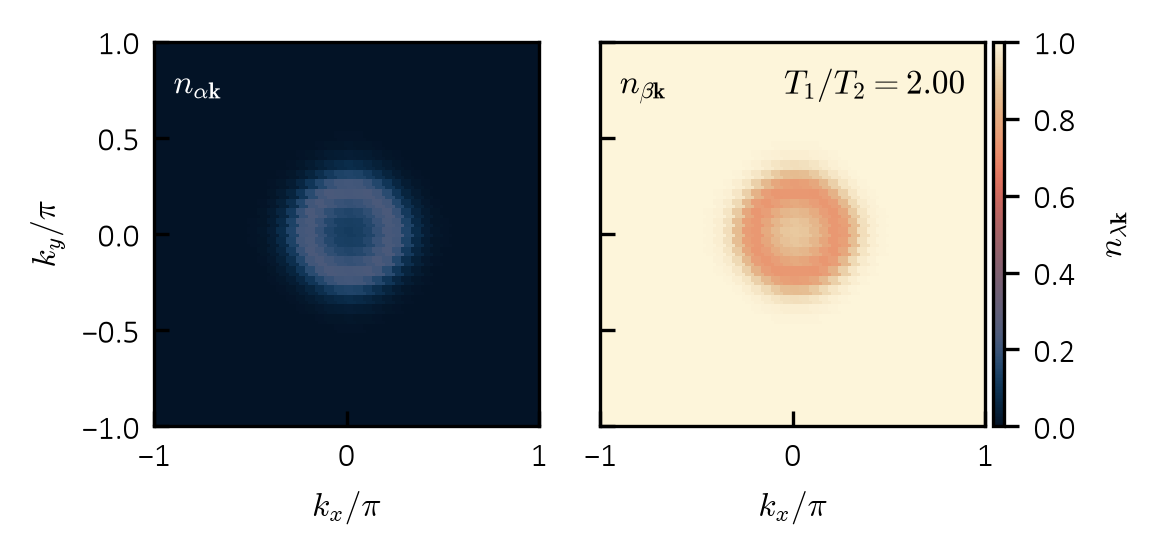

In [ ]:
q0 = 5

plot_nalpha_beta_bz(nfa, r, q0, OUT=OUT, name="nalpha_beta_bz_q3", save=False, overwrite=True)

Plotting: 100%|██████████| 16/16 [00:00<00:00, 2090.29it/s]
/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


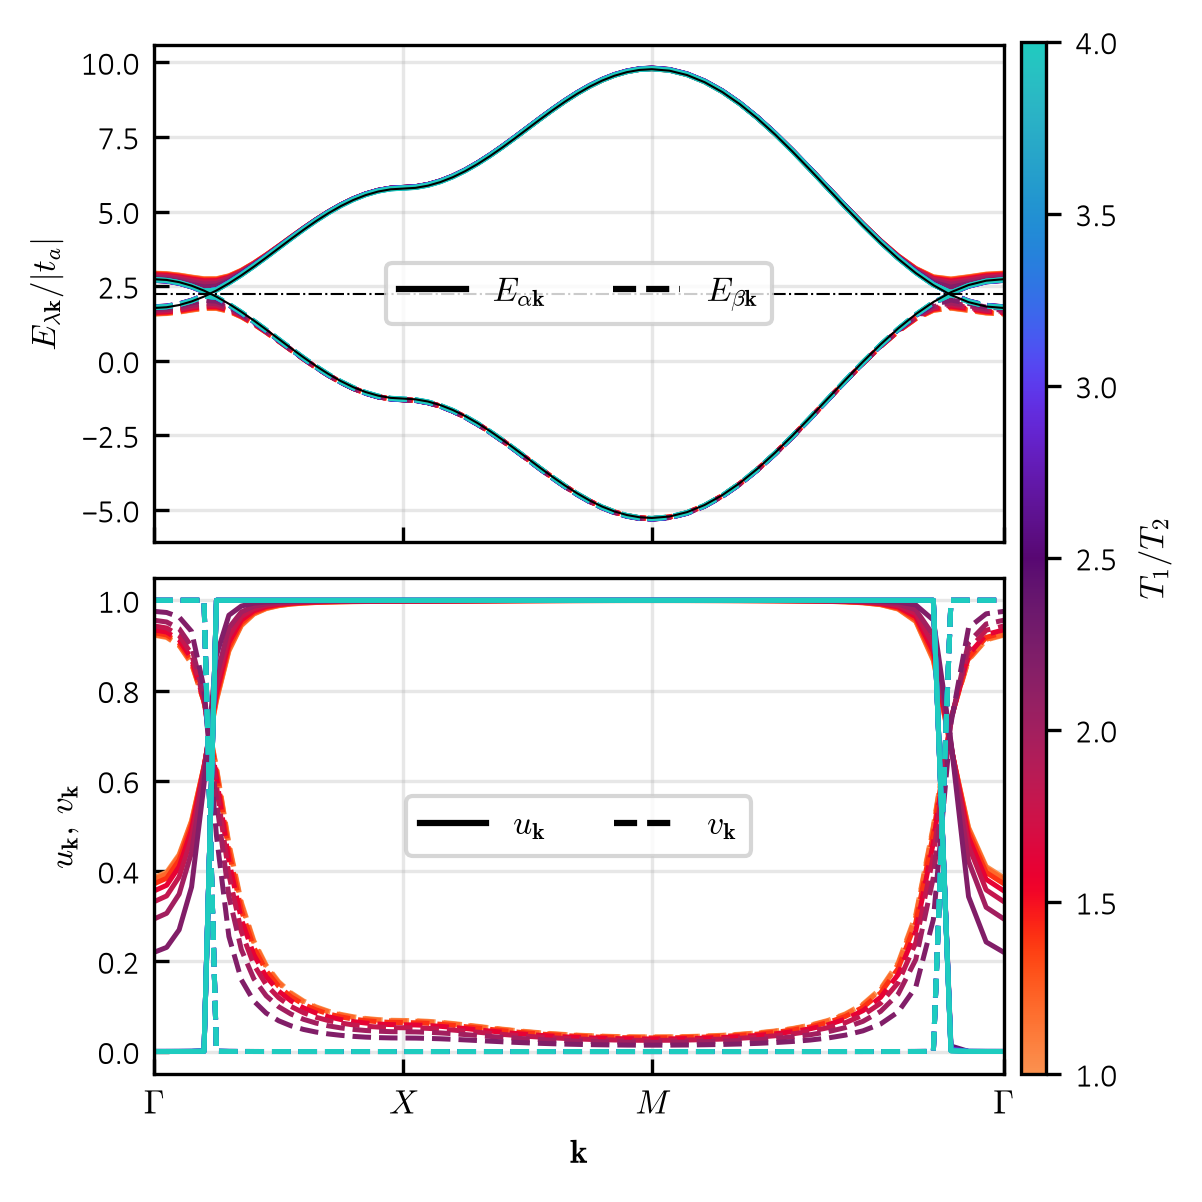

In [ ]:
ra = r

plot_energies_uv(eaa, eba, ua, va, eah, ebh, ra, ks, kt, kl,
                 OUT=OUT, name="energies_uv_b2", save=False, overwrite=True, Ec=Ec)

In [ ]:
# q0 = 9

# x1 = x1a[q0]
# x2 = x2a[q0]

# t1 = x1 * tc
# t2 = x2 * tc
# te = t0

# logger.info(f"T1/Tc = {x1}")
# logger.info(f"T2/Tc = {x2}")
# logger.info(f"T1/T2 = {t1 / t2}")
# logger.info(f"Teq/Tc = {te / tc}")

In [ ]:
# def mkbs(t1, t2):
#     return (
#         ej.gam_db(t=t1, name="bath 1", **bpars),
#         ej.gam_db(t=t2, name="bath 2", **bpars),
#     )

In [ ]:
# se = eu.solve_eq(
#     bd_dense, p,
#     t=te,
#     d=max(abs(s0.d), 1.0e-4),
#     m=s0.m,
#     **eq["solve"],
# )

# nfd = np.asarray(se.n).copy()

In [ ]:
# os = cfg["open_system"]["solve"]

In [ ]:
# def run(t1, t2, si, lab):
    

#     n = np.asarray(si.n, dtype=np.float32).copy()
#     d, m = float(si.d), float(si.m)

#     assert n.shape == (2, bd_dense.size)

#     tt, it = 0.0, 0

#     ht, hd, hm, hr = [0.0], [d], [m], [np.nan]
#     hnt, hn = [0.0], [n.copy()]

#     bs = mkbs(t1, t2)

#     nstep = 5 * os["chk"]
#     nf = (os["nmax"] + nstep - 1) // nstep
#     bar = tqdm(range(nf), desc=lab)

#     for q in bar:
#         ns = min(nstep, os["nmax"] - it)
#         ck = min(os["chk"], ns)
#         ts = tt

#         so = ej.solve_open(
#             bd_dense, p, n, bs, d=d, m=m,
#             dt=os["dt"], td=os["td"], tm=os["tm"],
#             tol= 1e-6, nmax=ns, chk=ck,
#             prog=False, mode="block", block=512,
#         )

#         th = np.asarray(so.hist["t"], dtype=float)
#         ih = np.asarray(so.hist["it"], dtype=int)
#         dh = np.asarray(so.hist["d"], dtype=float)
#         mh = np.asarray(so.hist["m"], dtype=float)
#         rh = np.asarray(so.hist["err"], dtype=float)

#         ht.extend(ts + th)
#         hd.extend(dh)
#         hm.extend(mh)
#         hr.extend(rh)

#         n = so.n.copy()
#         d, m = float(so.d), float(so.m)

#         tt = ts + float(th[-1])
#         it += int(ih[-1])
#         er0 = float(rh[-1])

#         hnt.append(tt)
#         hn.append(n.copy())

#         bar.set_postfix(
#             it=it, t=f"{tt:.2f}",
#             d=f"{abs(d):.4f}",
#             m=f"{m:.4f}",
#             err=f"{er0:.2e}",
#         )

#         if er0 <  1e-6:
#             break

#     return {
#         "t": np.asarray(ht),
#         "d": np.asarray(hd),
#         "m": np.asarray(hm),
#         "er": np.asarray(hr),
#         "tn": np.asarray(hnt),
#         "n": np.asarray(hn),
#         "st": so.st,
#         "it": it,
#         "ok": er0 < 1e-6,
#     }

In [ ]:
# hn = run(t1, t2, s0, "Unequal baths")
# he = run(te, te, s0, "Equal baths")

# logger.info(f"Unequal converged {hn["ok"]}")
# logger.info(f"Unequal error: {hn["er"][-1]}")
# logger.info(f"Unequal iterations: {hn["it"]}")
# logger.info(f"Equal converged: {he["ok"]}")
# logger.info(f"Equal error: {he["er"][-1]}")
# logger.info(f"Equal iterations: {he["it"]}")

In [ ]:
# nfd = np.asarray(se.n)

# print(
#     "Equal bath vs FD:",
#     np.max(np.abs(he["n"][-1] - nfd)),
# )

# print(
#     "Delta difference:",
#     abs(he["d"][-1] - se.d),
# )

# print(
#     "m difference:",
#     abs(he["m"][-1] - se.m),
# )

In [ ]:
# dn = np.max(np.abs(hn["n"] - hn["n"][-1]), axis=2)
# de = np.max(np.abs(he["n"] - he["n"][-1]), axis=2)

# ka = bpars["kap"][0]

# xn = ka * hn["t"]
# xe = ka * he["t"]
# xnn = ka * hn["tn"]
# xne = ka * he["tn"]

# xm = max(xn[-1], xe[-1])
# dref = max(abs(s0.d), 1.0e-12)

# h = 1.15
# fig, ax = plt.subplots(2, 2, figsize=(3.47412, h * 3.47412))

# ax[0, 0].plot(xn, np.abs(hn["d"]) / dref, color=set1_list[0], label=r"$T_1\neq T_2$")
# ax[0, 0].plot(xe, np.abs(he["d"]) / dref, color=set1_list[1], label=r"$T_1=T_2$")
# ax[0, 0].axhline(abs(se.d) / dref, color="black", linestyle="--", label="FD eq.")
# ax[0, 0].set_xlabel(r"$\kappa_{\alpha\alpha}t$")
# ax[0, 0].set_ylabel(r"$|\Delta(t)|/\Delta_0$")

# ax[0, 1].plot(xn, hn["m"], color=set1_list[0], label=r"$T_1\neq T_2$")
# ax[0, 1].plot(xe, he["m"], color=set1_list[1], label=r"$T_1=T_2$")
# ax[0, 1].axhline(se.m, color="black", linestyle="--", label="FD eq.")
# ax[0, 1].set_xlabel(r"$\kappa_{\alpha\alpha}t$")
# ax[0, 1].set_ylabel(r"$m(t)$")

# ax[1, 0].semilogy(xnn, np.maximum(dn[:, 0], 1.0e-12), color=set1_list[0], label=r"$\alpha$, $T_1\neq T_2$")
# ax[1, 0].semilogy(xnn, np.maximum(dn[:, 1], 1.0e-12), color=set1_list[1], label=r"$\beta$, $T_1\neq T_2$")
# ax[1, 0].semilogy(xne, np.maximum(de[:, 0], 1.0e-12), color=set1_list[2], linestyle="--", label=r"$\alpha$, $T_1=T_2$")
# ax[1, 0].semilogy(xne, np.maximum(de[:, 1], 1.0e-12), color=set1_list[3], linestyle="--", label=r"$\beta$, $T_1=T_2$")
# ax[1, 0].set_xlabel(r"$\kappa_{\alpha\alpha}t$")
# ax[1, 0].set_ylabel(r"$\max_{\mathbf{k}}|n(t)-n_{\rm ss}|$")

# ax[1, 1].semilogy(xn[1:], np.maximum(hn["er"][1:], 1.0e-12), color=set1_list[0], label=r"$T_1\neq T_2$")
# ax[1, 1].semilogy(xe[1:], np.maximum(he["er"][1:], 1.0e-12), color=set1_list[1], label=r"$T_1=T_2$")
# ax[1, 1].set_xlabel(r"$\kappa_{\alpha\alpha}t$")
# ax[1, 1].set_ylabel(r"$\epsilon$")

# for a in tqdm(ax.ravel(), desc="Formatting"):
#     a.set_xlim(0.0, xm)
#     a.grid(alpha=0.3)
#     a.legend(fontsize=6)

# plt.tight_layout()
# plt.show()

In [ ]:
# pn = np.empty((hn["n"].shape[0], 2, ks.size))

# for q in tqdm(range(hn["n"].shape[0]), desc="Projecting occupations"):
#     pn[q, 0] = path1(hn["n"][q, 0])
#     pn[q, 1] = path1(hn["n"][q, 1])

In [ ]:
# nn = np.stack((path1(hn["n"][-1, 0]), path1(hn["n"][-1, 1])))
# ne = np.stack((path1(he["n"][-1, 0]), path1(he["n"][-1, 1])))
# ff = np.stack((path1(nfd[0]), path1(nfd[1])))

In [ ]:
# h = 0.9
# fig, ax = plt.subplots(
#     2, 1, figsize=(3.47412, h * 3.47412),
#     sharex=True,
# )

# ax[0].plot(ks, nn[0], color=set1_list[0], label=rf"$T_1/T_c={x1:.2f},\ T_2/T_c={x2:.2f}$")
# ax[0].plot(ks, ne[0], color=set1_list[1], label=rf"$T_1=T_2={te / tc:.2f}T_c$")
# ax[0].plot(ks, ff[0], color="black", linestyle="--", label="FD")

# ax[1].plot(ks, nn[1], color=set1_list[0], label=rf"$T_1/T_c={x1:.2f},\ T_2/T_c={x2:.2f}$")
# ax[1].plot(ks, ne[1], color=set1_list[1], label=rf"$T_1=T_2={te / tc:.2f}T_c$")
# ax[1].plot(ks, ff[1], color="black", linestyle="--", label="FD")

# ax[0].set_xlabel(r"$\mathbf{k}$")
# ax[1].set_xlabel(r"$\mathbf{k}$")
# ax[0].set_ylabel(r"$n_{\alpha\mathbf{k}}$")
# ax[1].set_ylabel(r"$n_{\beta\mathbf{k}}$")

# ax[1].set_xticks(kt)
# ax[1].set_xticklabels(kl)

# for a in tqdm(ax, desc="Formatting"):
#     a.set_xlim(ks[0], ks[-1])
#     a.set_ylim(0.0, 1.0)
#     a.grid(alpha=0.3)
#     a.legend(
#         bbox_to_anchor=(0, 1.02, 1, 0.2),
#         loc="lower left", mode="expand",
#         borderaxespad=0, ncol=3, fontsize=6,
#     )

# plt.tight_layout()
# plt.show()

In [ ]:
# yn = hn["n"][-1]
# en = np.asarray(hn["st"].e)

# ye = he["n"][-1]
# eee = np.asarray(he["st"].e)

# ep = np.finfo(np.float32).eps

# zn = np.log(
#     (1.0 - np.clip(yn, ep, 1.0 - ep))
#     / np.clip(yn, ep, 1.0 - ep)
# )

# ze = np.log(
#     (1.0 - np.clip(ye, ep, 1.0 - ep))
#     / np.clip(ye, ep, 1.0 - ep)
# )

# ww = np.broadcast_to(
#     np.asarray(bd_dense.w),
#     (2, bd_dense.size),
# )

# mn = (yn > 1.0e-4) & (yn < 1.0 - 1.0e-4)
# me = (ye > 1.0e-4) & (ye < 1.0 - 1.0e-4)

# cn = np.polyfit(
#     en[mn],
#     zn[mn],
#     1,
#     w=np.sqrt(ww[mn]),
# )

# tfit = 1.0 / cn[0]
# mufit = -cn[1] / cn[0]

# rn = np.sqrt(
#     np.average(
#         (zn[mn] - np.polyval(cn, en[mn])) ** 2,
#         weights=ww[mn],
#     )
# )

# ree = np.sqrt(
#     np.average(
#         (ze[me] - (eee[me] - se.mu) / te) ** 2,
#         weights=ww[me],
#     )
# )

# print("Unequal best-fit T:", tfit)
# print("Unequal best-fit mu:", mufit)
# print("Unequal FD residual:", rn)
# print("Equal FD residual:", ree)

In [ ]:
# from scipy.optimize import least_squares

# def fd(e, mu, t):
#     z = np.clip((e - mu) / t, -80.0, 80.0)
#     return 1.0 / (1.0 + np.exp(z))

In [ ]:
# en = np.asarray(hn["st"].e)
# yn = np.asarray(hn["n"][-1])

# ee = np.asarray(he["st"].e)
# ye = np.asarray(he["n"][-1])

# w = np.tile(np.asarray(bd_dense.w), 2)
# ef = en.reshape(-1)
# yf = yn.reshape(-1)

# def res(z):
#     mu = z[0]
#     t = np.exp(z[1])
#     return np.sqrt(w) * (fd(ef, mu, t) - yf)

# ls = least_squares(
#     res,
#     x0=np.array([se.mu, np.log(te)]),
# )

# muf = ls.x[0]
# tf = np.exp(ls.x[1])

# fn = fd(en, muf, tf)
# fe = fd(ee, se.mu, te)

# rn = np.sqrt(
#     np.sum(w * (yn.reshape(-1) - fn.reshape(-1)) ** 2)
#     / np.sum(w)
# )

# re = np.sqrt(
#     np.sum(w * (ye.reshape(-1) - fe.reshape(-1)) ** 2)
#     / np.sum(w)
# )

# print("Unequal best-fit T/Tc:", tf / tc)
# print("Unequal best-fit mu:", muf)
# print("Unequal FD RMS error:", rn)
# print("Equal FD RMS error:", re)

In [ ]:
# egn = np.linspace(en.min(), en.max(), 500)
# ege = np.linspace(ee.min(), ee.max(), 500)

# h = 0.62
# fig, ax = plt.subplots(
#     1, 2,
#     figsize=(3.47412, h * 3.47412),
#     sharey=True,
# )

# ax[0].scatter(
#     en[0], yn[0],
#     s=3, alpha=0.35,
#     color=set1_list[0],
#     label=r"$n_{\alpha\mathbf{k}}$",
# )

# ax[0].scatter(
#     en[1], yn[1],
#     s=3, alpha=0.35,
#     color=set1_list[1],
#     label=r"$n_{\beta\mathbf{k}}$",
# )

# ax[0].plot(
#     egn,
#     fd(egn, muf, tf),
#     color=set1_list[2],
#     linewidth=1.5,
#     label=rf"best FD, $T/T_c={tf / tc:.2f}$",
# )

# ax[1].scatter(
#     ee[0], ye[0],
#     s=3, alpha=0.35,
#     color=set1_list[0],
#     label=r"$n_{\alpha\mathbf{k}}$",
# )

# ax[1].scatter(
#     ee[1], ye[1],
#     s=3, alpha=0.35,
#     color=set1_list[1],
#     label=r"$n_{\beta\mathbf{k}}$",
# )

# ax[1].plot(
#     ege,
#     fd(ege, se.mu, te),
#     color=set1_list[2],
#     linewidth=1.5,
#     label=rf"FD, $T/T_c={te / tc:.2f}$",
# )

# ax[0].text(
#     0.05, 0.08,
#     r"$T_1\neq T_2$",
#     transform=ax[0].transAxes,
# )

# ax[1].text(
#     0.05, 0.08,
#     r"$T_1=T_2$",
#     transform=ax[1].transAxes,
# )

# ax[0].set_xlim(egn[0], egn[-1])
# ax[1].set_xlim(ege[0], ege[-1])
# ax[0].set_ylim(0.0, 1.0)

# ax[0].set_xlabel(r"$E_{\lambda\mathbf{k}}/|t_a|$")
# ax[1].set_xlabel(r"$E_{\lambda\mathbf{k}}/|t_a|$")
# ax[0].set_ylabel(r"$n_{\lambda\mathbf{k}}$")
# ax[1].set_ylabel(r"$n_{\lambda\mathbf{k}}$")

# ax[0].grid(alpha=0.3)
# ax[1].grid(alpha=0.3)
# ax[0].legend(fontsize=6)
# ax[1].legend(fontsize=6)

# plt.tight_layout()
# plt.show()

In [ ]:
# stn = ej.mf_state(
#     bd_dense, p,
#     d=hn["d"][-1],
#     m=hn["m"][-1],
# )

# steq = ej.mf_state(
#     bd_dense, p,
#     d=he["d"][-1],
#     m=he["m"][-1],
# )

# yn = np.asarray(hn["n"][-1])
# ye = np.asarray(he["n"][-1])

# en = np.asarray(stn.e)
# ee = np.asarray(steq.e)

# qfn = fd(en, muf, tf)
# qfe = fd(ee, se.mu, te)

In [ ]:
# na_n, nb_n = ej.band_occ(stn, yn)
# na_f, nb_f = ej.band_occ(stn, qfn)

# na_e, nb_e = ej.band_occ(steq, ye)
# na_ef, nb_ef = ej.band_occ(steq, qfe)

# na_n = np.asarray(na_n)
# nb_n = np.asarray(nb_n)
# na_f = np.asarray(na_f)
# nb_f = np.asarray(nb_f)

# na_e = np.asarray(na_e)
# nb_e = np.asarray(nb_e)
# na_ef = np.asarray(na_ef)
# nb_ef = np.asarray(nb_ef)

In [ ]:
# w = np.asarray(bd_dense.w)

# ea_n = np.sqrt(np.sum(w * (na_n - na_f) ** 2))
# eb_n = np.sqrt(np.sum(w * (nb_n - nb_f) ** 2))

# ea_e = np.sqrt(np.sum(w * (na_e - na_ef) ** 2))
# eb_e = np.sqrt(np.sum(w * (nb_e - nb_ef) ** 2))

# print("Unequal a-band FD error:", ea_n)
# print("Unequal b-band FD error:", eb_n)

# print("Equal a-band FD error:", ea_e)
# print("Equal b-band FD error:", eb_e)

In [ ]:
# eah_n = np.asarray(stn.eah)
# ebh_n = np.asarray(stn.ebh)

# eah_e = np.asarray(steq.eah)
# ebh_e = np.asarray(steq.ebh)

# ia_n = np.argsort(eah_n)
# ib_n = np.argsort(ebh_n)

# ia_e = np.argsort(eah_e)
# ib_e = np.argsort(ebh_e)

In [ ]:
# h = 1.15
# fig, ax = plt.subplots(
#     2, 2,
#     figsize=(3.47412, h * 3.47412),
#     sharey=True,
# )

# ax[0, 0].scatter(
#     eah_n, na_n,
#     s=3, alpha=0.3,
#     color=set1_list[0],
#     label=r"$n_{a\mathbf{k}}$",
# )

# ax[0, 0].plot(
#     eah_n[ia_n], na_f[ia_n],
#     color=set1_list[2],
#     linewidth=1.3,
#     label="rotated FD fit",
# )

# ax[0, 1].scatter(
#     ebh_n, nb_n,
#     s=3, alpha=0.3,
#     color=set1_list[1],
#     label=r"$n_{b\mathbf{k}}$",
# )

# ax[0, 1].plot(
#     ebh_n[ib_n], nb_f[ib_n],
#     color=set1_list[2],
#     linewidth=1.3,
#     label="rotated FD fit",
# )

# ax[1, 0].scatter(
#     eah_e, na_e,
#     s=3, alpha=0.3,
#     color=set1_list[0],
#     label=r"$n_{a\mathbf{k}}$",
# )

# ax[1, 0].plot(
#     eah_e[ia_e], na_ef[ia_e],
#     color=set1_list[2],
#     linewidth=1.3,
#     label="rotated FD",
# )

# ax[1, 1].scatter(
#     ebh_e, nb_e,
#     s=3, alpha=0.3,
#     color=set1_list[1],
#     label=r"$n_{b\mathbf{k}}$",
# )

# ax[1, 1].plot(
#     ebh_e[ib_e], nb_ef[ib_e],
#     color=set1_list[2],
#     linewidth=1.3,
#     label="rotated FD",
# )

# ax[0, 0].text(
#     0.05, 0.08,
#     r"$T_1\neq T_2$",
#     transform=ax[0, 0].transAxes,
# )

# ax[0, 1].text(
#     0.05, 0.08,
#     r"$T_1\neq T_2$",
#     transform=ax[0, 1].transAxes,
# )

# ax[1, 0].text(
#     0.05, 0.08,
#     r"$T_1=T_2$",
#     transform=ax[1, 0].transAxes,
# )

# ax[1, 1].text(
#     0.05, 0.08,
#     r"$T_1=T_2$",
#     transform=ax[1, 1].transAxes,
# )

# # ax[0, 0].set_xlim(eah_n.min(), eah_n.max())
# # ax[0, 1].set_xlim(ebh_n.min(), ebh_n.max())
# # ax[1, 0].set_xlim(eah_e.min(), eah_e.max())
# # ax[1, 1].set_xlim(ebh_e.min(), ebh_e.max())

# ax[0, 0].set_xlabel(r"$E^{\rm H}_{a\mathbf{k}}/|t_a|$")
# ax[1, 0].set_xlabel(r"$E^{\rm H}_{a\mathbf{k}}/|t_a|$")
# ax[0, 1].set_xlabel(r"$E^{\rm H}_{b\mathbf{k}}/|t_a|$")
# ax[1, 1].set_xlabel(r"$E^{\rm H}_{b\mathbf{k}}/|t_a|$")

# ax[0, 0].set_ylabel(r"$n_{a\mathbf{k}}$")
# ax[1, 0].set_ylabel(r"$n_{a\mathbf{k}}$")
# ax[0, 1].set_ylabel(r"$n_{b\mathbf{k}}$")
# ax[1, 1].set_ylabel(r"$n_{b\mathbf{k}}$")

# for a in tqdm(ax.ravel(), desc="Formatting"):
#     a.set_ylim(0.0, 1.0)
#     a.grid(alpha=0.3)
#     a.legend(fontsize=6)

# plt.tight_layout()
# plt.show()